<a href="https://colab.research.google.com/github/Usman-938/AI-ML-Internship-Tasks-/blob/main/Task2_ML_Pipeline_Telco_Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 2: End-to-End ML Pipeline with Scikit-learn Pipeline API

**Objective:** Build a reusable and production-ready machine learning pipeline for predicting customer churn.

**Student:** Muhammad Usman Ilyas  
**University:** Abdul Wali Khan University Mardan (AWKUM)  
**Program:** BS Artificial Intelligence  

---

## Problem Statement & Objective

Customer churn — when a customer stops using a service — is a critical business problem in the telecom industry. Acquiring a new customer costs 5–25× more than retaining an existing one. This notebook builds a **production-ready, reusable ML pipeline** using Scikit-learn's `Pipeline` API to predict which customers are likely to churn from a telecom company.

**Pipeline covers:**
- Automated data preprocessing (scaling, encoding) inside `Pipeline`
- Training two models: Logistic Regression and Random Forest
- Hyperparameter tuning with `GridSearchCV`
- Full evaluation with metrics and visualizations
- Exporting the final pipeline with `joblib` for deployment

## Step 1 — Install & Import Libraries

In [1]:
# Install any missing packages
!pip install -q scikit-learn pandas numpy matplotlib seaborn joblib
print('Packages ready!')

Packages ready!


In [2]:
# ── Standard Library ──────────────────────────────────────────────
import warnings
import os
warnings.filterwarnings('ignore')

# ── Data Handling ─────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ── Scikit-learn: Preprocessing ───────────────────────────────────
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer

# ── Scikit-learn: Models ──────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# ── Scikit-learn: Tuning & Evaluation ─────────────────────────────
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve, ConfusionMatrixDisplay
)

# ── Model Export ──────────────────────────────────────────────────
import joblib

# ── Style ─────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('All libraries imported successfully!')
print(f'Scikit-learn version : {__import__("sklearn").__version__}')
print(f'Pandas version       : {pd.__version__}')
print(f'NumPy version        : {np.__version__}')

All libraries imported successfully!
Scikit-learn version : 1.6.1
Pandas version       : 2.2.2
NumPy version        : 2.0.2


## Step 2 — Dataset Loading & Preprocessing

We use the **IBM Telco Customer Churn** dataset — the standard benchmark for churn prediction. It contains 7,043 customers and 21 features including demographics, account information, and service subscriptions.

Dataset source: [IBM Sample Data Sets](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)

In [3]:
# ── Load Dataset ──────────────────────────────────────────────────
# Option A: Load from URL (no download needed)
URL = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'

try:
    df = pd.read_csv(URL)
    print(f'Dataset loaded from URL. Shape: {df.shape}')
except Exception:
    # Option B: Synthetic fallback if no internet
    print('URL failed — generating synthetic Telco dataset...')
    np.random.seed(42)
    n = 7043
    df = pd.DataFrame({
        'customerID'      : [f'ID-{i:05d}' for i in range(n)],
        'gender'          : np.random.choice(['Male','Female'], n),
        'SeniorCitizen'   : np.random.choice([0, 1], n, p=[0.84, 0.16]),
        'Partner'         : np.random.choice(['Yes','No'], n),
        'Dependents'      : np.random.choice(['Yes','No'], n, p=[0.3, 0.7]),
        'tenure'          : np.random.randint(0, 72, n),
        'PhoneService'    : np.random.choice(['Yes','No'], n, p=[0.9, 0.1]),
        'MultipleLines'   : np.random.choice(['Yes','No','No phone service'], n),
        'InternetService' : np.random.choice(['DSL','Fiber optic','No'], n),
        'OnlineSecurity'  : np.random.choice(['Yes','No','No internet service'], n),
        'OnlineBackup'    : np.random.choice(['Yes','No','No internet service'], n),
        'DeviceProtection': np.random.choice(['Yes','No','No internet service'], n),
        'TechSupport'     : np.random.choice(['Yes','No','No internet service'], n),
        'StreamingTV'     : np.random.choice(['Yes','No','No internet service'], n),
        'StreamingMovies' : np.random.choice(['Yes','No','No internet service'], n),
        'Contract'        : np.random.choice(['Month-to-month','One year','Two year'], n, p=[0.55,0.24,0.21]),
        'PaperlessBilling': np.random.choice(['Yes','No'], n),
        'PaymentMethod'   : np.random.choice(['Electronic check','Mailed check','Bank transfer (automatic)','Credit card (automatic)'], n),
        'MonthlyCharges'  : np.round(np.random.uniform(18, 120, n), 2),
        'TotalCharges'    : np.round(np.random.uniform(18, 8700, n), 2),
        'Churn'           : np.random.choice(['Yes','No'], n, p=[0.265, 0.735])
    })
    # Inject some blanks to simulate real data
    df.loc[np.random.choice(n, 11, replace=False), 'TotalCharges'] = np.nan
    print(f'Synthetic dataset created. Shape: {df.shape}')

print()
print('First 5 rows:')
df.head()

Dataset loaded from URL. Shape: (7043, 21)

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# ── Basic Info ────────────────────────────────────────────────────
print('Dataset Info:')
print(f'  Shape          : {df.shape}')
print(f'  Columns        : {list(df.columns)}')
print(f'  Missing values : {df.isnull().sum().sum()}')
print()
print('Data Types:')
print(df.dtypes)
print()
print('Target Distribution (Churn):')
print(df['Churn'].value_counts())
print(f'  Churn rate: {df["Churn"].value_counts(normalize=True)["Yes"]:.2%}')

Dataset Info:
  Shape          : (7043, 21)
  Columns        : ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']
  Missing values : 0

Data Types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn              

In [5]:
# ── Data Cleaning ─────────────────────────────────────────────────

# 1. Drop customerID (not a feature)
df.drop(columns=['customerID'], inplace=True, errors='ignore')

# 2. TotalCharges is often loaded as string — convert to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 3. Fill missing TotalCharges with median (11 rows)
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# 4. Encode target: Yes=1, No=0
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

# 5. SeniorCitizen is already 0/1 — keep as numeric

print('Cleaning complete!')
print(f'Missing values remaining : {df.isnull().sum().sum()}')
print(f'Final shape              : {df.shape}')
print()
print('Target value counts after encoding:')
print(df['Churn'].value_counts())

Cleaning complete!
Missing values remaining : 0
Final shape              : (7043, 20)

Target value counts after encoding:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [6]:
# ── Feature Identification ────────────────────────────────────────

# Separate features and target
X = df.drop(columns=['Churn'])
y = df['Churn']

# Identify numeric vs categorical columns
NUMERIC_FEATURES = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
CATEGORICAL_FEATURES = X.select_dtypes(include=['object']).columns.tolist()

print(f'Numeric features ({len(NUMERIC_FEATURES)})    : {NUMERIC_FEATURES}')
print(f'Categorical features ({len(CATEGORICAL_FEATURES)}) : {CATEGORICAL_FEATURES}')
print(f'Total features: {len(NUMERIC_FEATURES) + len(CATEGORICAL_FEATURES)}')

# Train / Test split — stratified to preserve churn ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'\nTrain set : {X_train.shape[0]} samples')
print(f'Test set  : {X_test.shape[0]} samples')
print(f'Train churn rate: {y_train.mean():.2%}')
print(f'Test churn rate : {y_test.mean():.2%}')

Numeric features (4)    : ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features (15) : ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Total features: 19

Train set : 5634 samples
Test set  : 1409 samples
Train churn rate: 26.54%
Test churn rate : 26.54%


## Step 3 — Exploratory Data Analysis (Visualizations)

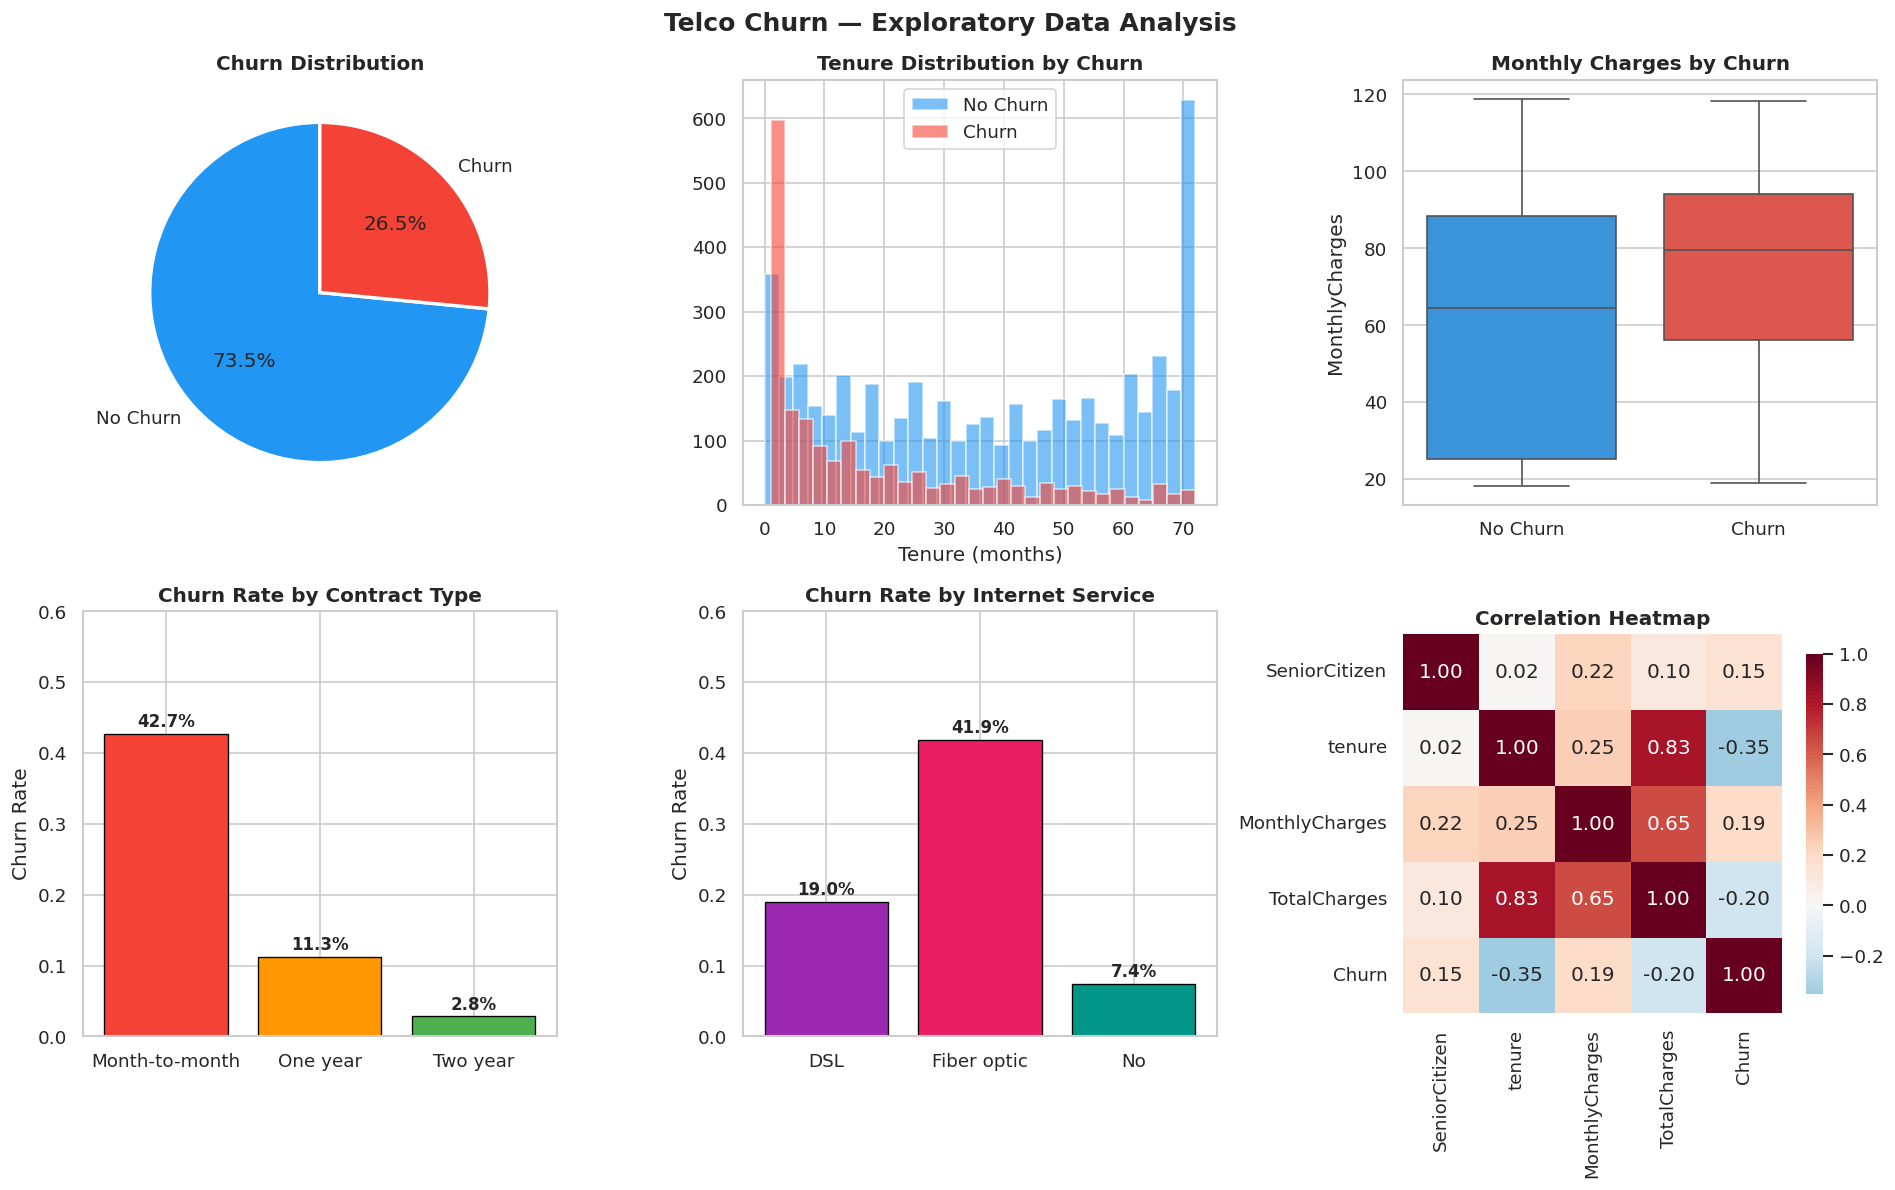

EDA plots saved!


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Telco Churn — Exploratory Data Analysis', fontsize=15, fontweight='bold')

churn_labels = {0: 'No Churn', 1: 'Churn'}
palette = {0: '#2196F3', 1: '#F44336'}

# 1. Target distribution
churn_counts = df['Churn'].value_counts()
axes[0,0].pie(
    churn_counts, labels=['No Churn', 'Churn'],
    colors=['#2196F3', '#F44336'],
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0,0].set_title('Churn Distribution', fontweight='bold')

# 2. Tenure distribution by churn
for churn_val, color in palette.items():
    subset = df[df['Churn'] == churn_val]['tenure']
    axes[0,1].hist(subset, bins=30, alpha=0.6, color=color,
                   label=churn_labels[churn_val], edgecolor='white')
axes[0,1].set_title('Tenure Distribution by Churn', fontweight='bold')
axes[0,1].set_xlabel('Tenure (months)')
axes[0,1].legend()

# 3. Monthly Charges by churn
df_plot = df.copy()
df_plot['Churn_label'] = df_plot['Churn'].map(churn_labels)
sns.boxplot(data=df_plot, x='Churn_label', y='MonthlyCharges',
            palette=['#2196F3', '#F44336'], ax=axes[0,2])
axes[0,2].set_title('Monthly Charges by Churn', fontweight='bold')
axes[0,2].set_xlabel('')

# 4. Contract type vs Churn
contract_churn = df.groupby('Contract')['Churn'].mean().sort_values(ascending=False)
axes[1,0].bar(contract_churn.index, contract_churn.values,
              color=['#F44336', '#FF9800', '#4CAF50'], edgecolor='black', linewidth=0.8)
axes[1,0].set_title('Churn Rate by Contract Type', fontweight='bold')
axes[1,0].set_ylabel('Churn Rate')
axes[1,0].set_ylim(0, 0.6)
for i, (idx, val) in enumerate(contract_churn.items()):
    axes[1,0].text(i, val + 0.01, f'{val:.1%}', ha='center', fontsize=10, fontweight='bold')

# 5. Internet Service vs Churn
internet_churn = df.groupby('InternetService')['Churn'].mean()
axes[1,1].bar(internet_churn.index, internet_churn.values,
              color=['#9C27B0', '#E91E63', '#009688'], edgecolor='black', linewidth=0.8)
axes[1,1].set_title('Churn Rate by Internet Service', fontweight='bold')
axes[1,1].set_ylabel('Churn Rate')
axes[1,1].set_ylim(0, 0.6)
for i, (idx, val) in enumerate(internet_churn.items()):
    axes[1,1].text(i, val + 0.01, f'{val:.1%}', ha='center', fontsize=10, fontweight='bold')

# 6. Correlation heatmap (numeric features)
corr = df[NUMERIC_FEATURES + ['Churn']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, ax=axes[1,2],
            cbar_kws={'shrink': 0.8})
axes[1,2].set_title('Correlation Heatmap', fontweight='bold')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('EDA plots saved!')

## Step 4 — Model Development: Build Scikit-learn Pipelines

Each pipeline contains:
1. **ColumnTransformer** — applies different preprocessing to numeric vs categorical features
   - Numeric: `SimpleImputer(median)` → `StandardScaler`
   - Categorical: `SimpleImputer(most_frequent)` → `OneHotEncoder`
2. **Classifier** — Logistic Regression or Random Forest

In [8]:
# ── Preprocessing Transformer ─────────────────────────────────────

# Numeric pipeline: impute missing → scale
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),   # Fill missing with median
    ('scaler',  StandardScaler())                    # Zero-mean, unit-variance scaling
])

# Categorical pipeline: impute missing → one-hot encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Fill missing with mode
    ('encoder', OneHotEncoder(handle_unknown='ignore',     # Ignore unseen categories
                               sparse_output=False))        # Return dense array
])

# Combine into ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer,     NUMERIC_FEATURES),
    ('cat', categorical_transformer, CATEGORICAL_FEATURES)
])

print('Preprocessor built:')
print(f'  Numeric    ({len(NUMERIC_FEATURES)} cols) : {NUMERIC_FEATURES}')
print(f'  Categorical ({len(CATEGORICAL_FEATURES)} cols) : {CATEGORICAL_FEATURES}')

Preprocessor built:
  Numeric    (4 cols) : ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
  Categorical (15 cols) : ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [9]:
# ── Pipeline 1: Logistic Regression ──────────────────────────────
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight='balanced'   # Handle class imbalance
    ))
])

# ── Pipeline 2: Random Forest ─────────────────────────────────────
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   RandomForestClassifier(
        random_state=42,
        class_weight='balanced',  # Handle class imbalance
        n_jobs=-1                 # Use all CPU cores
    ))
])

print('Pipelines created:')
print('  1. Logistic Regression Pipeline')
print('     Steps:', [s[0] for s in lr_pipeline.steps])
print('  2. Random Forest Pipeline')
print('     Steps:', [s[0] for s in rf_pipeline.steps])

Pipelines created:
  1. Logistic Regression Pipeline
     Steps: ['preprocessor', 'classifier']
  2. Random Forest Pipeline
     Steps: ['preprocessor', 'classifier']


## Step 5 — Training & Baseline Evaluation

In [10]:
import time

# ── Train both pipelines ──────────────────────────────────────────
print('Training Logistic Regression pipeline...')
t0 = time.time()
lr_pipeline.fit(X_train, y_train)
lr_time = time.time() - t0
print(f'  Done in {lr_time:.2f}s')

print('Training Random Forest pipeline...')
t0 = time.time()
rf_pipeline.fit(X_train, y_train)
rf_time = time.time() - t0
print(f'  Done in {rf_time:.2f}s')

# ── Baseline predictions ──────────────────────────────────────────
lr_pred       = lr_pipeline.predict(X_test)
lr_pred_proba = lr_pipeline.predict_proba(X_test)[:, 1]

rf_pred       = rf_pipeline.predict(X_test)
rf_pred_proba = rf_pipeline.predict_proba(X_test)[:, 1]

# ── Metrics ───────────────────────────────────────────────────────
def print_metrics(name, y_true, y_pred, y_proba):
    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_proba)
    print(f'\n{name}')
    print('=' * 55)
    print(f'  Accuracy : {acc:.4f}')
    print(f'  ROC-AUC  : {auc:.4f}')
    print()
    print(classification_report(y_true, y_pred, target_names=['No Churn', 'Churn']))

print_metrics('Logistic Regression (Baseline)', y_test, lr_pred, lr_pred_proba)
print_metrics('Random Forest (Baseline)',       y_test, rf_pred, rf_pred_proba)

Training Logistic Regression pipeline...
  Done in 0.08s
Training Random Forest pipeline...
  Done in 0.69s

Logistic Regression (Baseline)
  Accuracy : 0.7381
  ROC-AUC  : 0.8413

              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409


Random Forest (Baseline)
  Accuracy : 0.7842
  ROC-AUC  : 0.8193

              precision    recall  f1-score   support

    No Churn       0.82      0.90      0.86      1035
       Churn       0.62      0.47      0.54       374

    accuracy                           0.78      1409
   macro avg       0.72      0.68      0.70      1409
weighted avg       0.77      0.78      0.77      1409



## Step 6 — Hyperparameter Tuning with GridSearchCV

In [11]:
# ── CV Strategy ───────────────────────────────────────────────────
# StratifiedKFold preserves churn ratio in each fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── Grid 1: Logistic Regression ───────────────────────────────────
# Note: param names use double-underscore — <step_name>__<param_name>
lr_param_grid = {
    'classifier__C'      : [0.01, 0.1, 1.0, 10.0],   # Regularisation strength
    'classifier__penalty': ['l1', 'l2'],               # Regularisation type
    'classifier__solver' : ['liblinear']               # Supports both l1 and l2
}

print('Running GridSearchCV for Logistic Regression...')
print(f'Grid size: {4 * 2 * 1} combinations × 5 folds = {4*2*1*5} fits')
t0 = time.time()

lr_grid_search = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=lr_param_grid,
    cv=cv,
    scoring='roc_auc',     # Optimise for AUC — better for imbalanced data
    n_jobs=-1,
    verbose=1,
    refit=True             # Refit best model on full training set
)
lr_grid_search.fit(X_train, y_train)
print(f'Done in {time.time()-t0:.1f}s')
print(f'Best params : {lr_grid_search.best_params_}')
print(f'Best CV AUC : {lr_grid_search.best_score_:.4f}')

Running GridSearchCV for Logistic Regression...
Grid size: 8 combinations × 5 folds = 40 fits
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Done in 11.0s
Best params : {'classifier__C': 10.0, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}
Best CV AUC : 0.8462


In [12]:
# ── Grid 2: Random Forest ─────────────────────────────────────────
rf_param_grid = {
    'classifier__n_estimators'     : [100, 200],        # Number of trees
    'classifier__max_depth'        : [None, 10, 20],    # Max tree depth
    'classifier__min_samples_split': [2, 5],            # Min samples to split node
    'classifier__max_features'     : ['sqrt', 'log2']   # Features per split
}

total_fits = 2 * 3 * 2 * 2 * 5
print('Running GridSearchCV for Random Forest...')
print(f'Grid size: 2×3×2×2 = 24 combinations × 5 folds = {total_fits} fits')
t0 = time.time()

rf_grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1,
    refit=True
)
rf_grid_search.fit(X_train, y_train)
print(f'Done in {time.time()-t0:.1f}s')
print(f'Best params : {rf_grid_search.best_params_}')
print(f'Best CV AUC : {rf_grid_search.best_score_:.4f}')

Running GridSearchCV for Random Forest...
Grid size: 2×3×2×2 = 24 combinations × 5 folds = 120 fits
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Done in 75.3s
Best params : {'classifier__max_depth': 10, 'classifier__max_features': 'log2', 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
Best CV AUC : 0.8434


## Step 7 — Evaluation with Relevant Metrics

In [13]:
# ── Best model predictions ────────────────────────────────────────
best_lr = lr_grid_search.best_estimator_
best_rf = rf_grid_search.best_estimator_

lr_pred_tuned       = best_lr.predict(X_test)
lr_pred_proba_tuned = best_lr.predict_proba(X_test)[:, 1]

rf_pred_tuned       = best_rf.predict(X_test)
rf_pred_proba_tuned = best_rf.predict_proba(X_test)[:, 1]

print_metrics('Logistic Regression (Tuned)', y_test, lr_pred_tuned, lr_pred_proba_tuned)
print_metrics('Random Forest (Tuned)',       y_test, rf_pred_tuned, rf_pred_proba_tuned)

# ── Summary comparison table ──────────────────────────────────────
print('\n' + '='*65)
print('MODEL COMPARISON SUMMARY')
print('='*65)
rows = []
for name, pred, proba in [
    ('LR  Baseline', lr_pred,       lr_pred_proba),
    ('LR  Tuned',    lr_pred_tuned, lr_pred_proba_tuned),
    ('RF  Baseline', rf_pred,       rf_pred_proba),
    ('RF  Tuned',    rf_pred_tuned, rf_pred_proba_tuned)
]:
    rows.append({
        'Model'   : name,
        'Accuracy': f'{accuracy_score(y_test, pred):.4f}',
        'ROC-AUC' : f'{roc_auc_score(y_test, proba):.4f}'
    })
comparison_df = pd.DataFrame(rows)
print(comparison_df.to_string(index=False))


Logistic Regression (Tuned)
  Accuracy : 0.7395
  ROC-AUC  : 0.8406

              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409


Random Forest (Tuned)
  Accuracy : 0.7637
  ROC-AUC  : 0.8379

              precision    recall  f1-score   support

    No Churn       0.89      0.78      0.83      1035
       Churn       0.54      0.72      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.76      0.77      1409


MODEL COMPARISON SUMMARY
       Model Accuracy ROC-AUC
LR  Baseline   0.7381  0.8413
   LR  Tuned   0.7395  0.8406
RF  Baseline   0.7842  0.8193
   RF  Tuned   0.7637  0.8379


## Step 8 — Visualizations

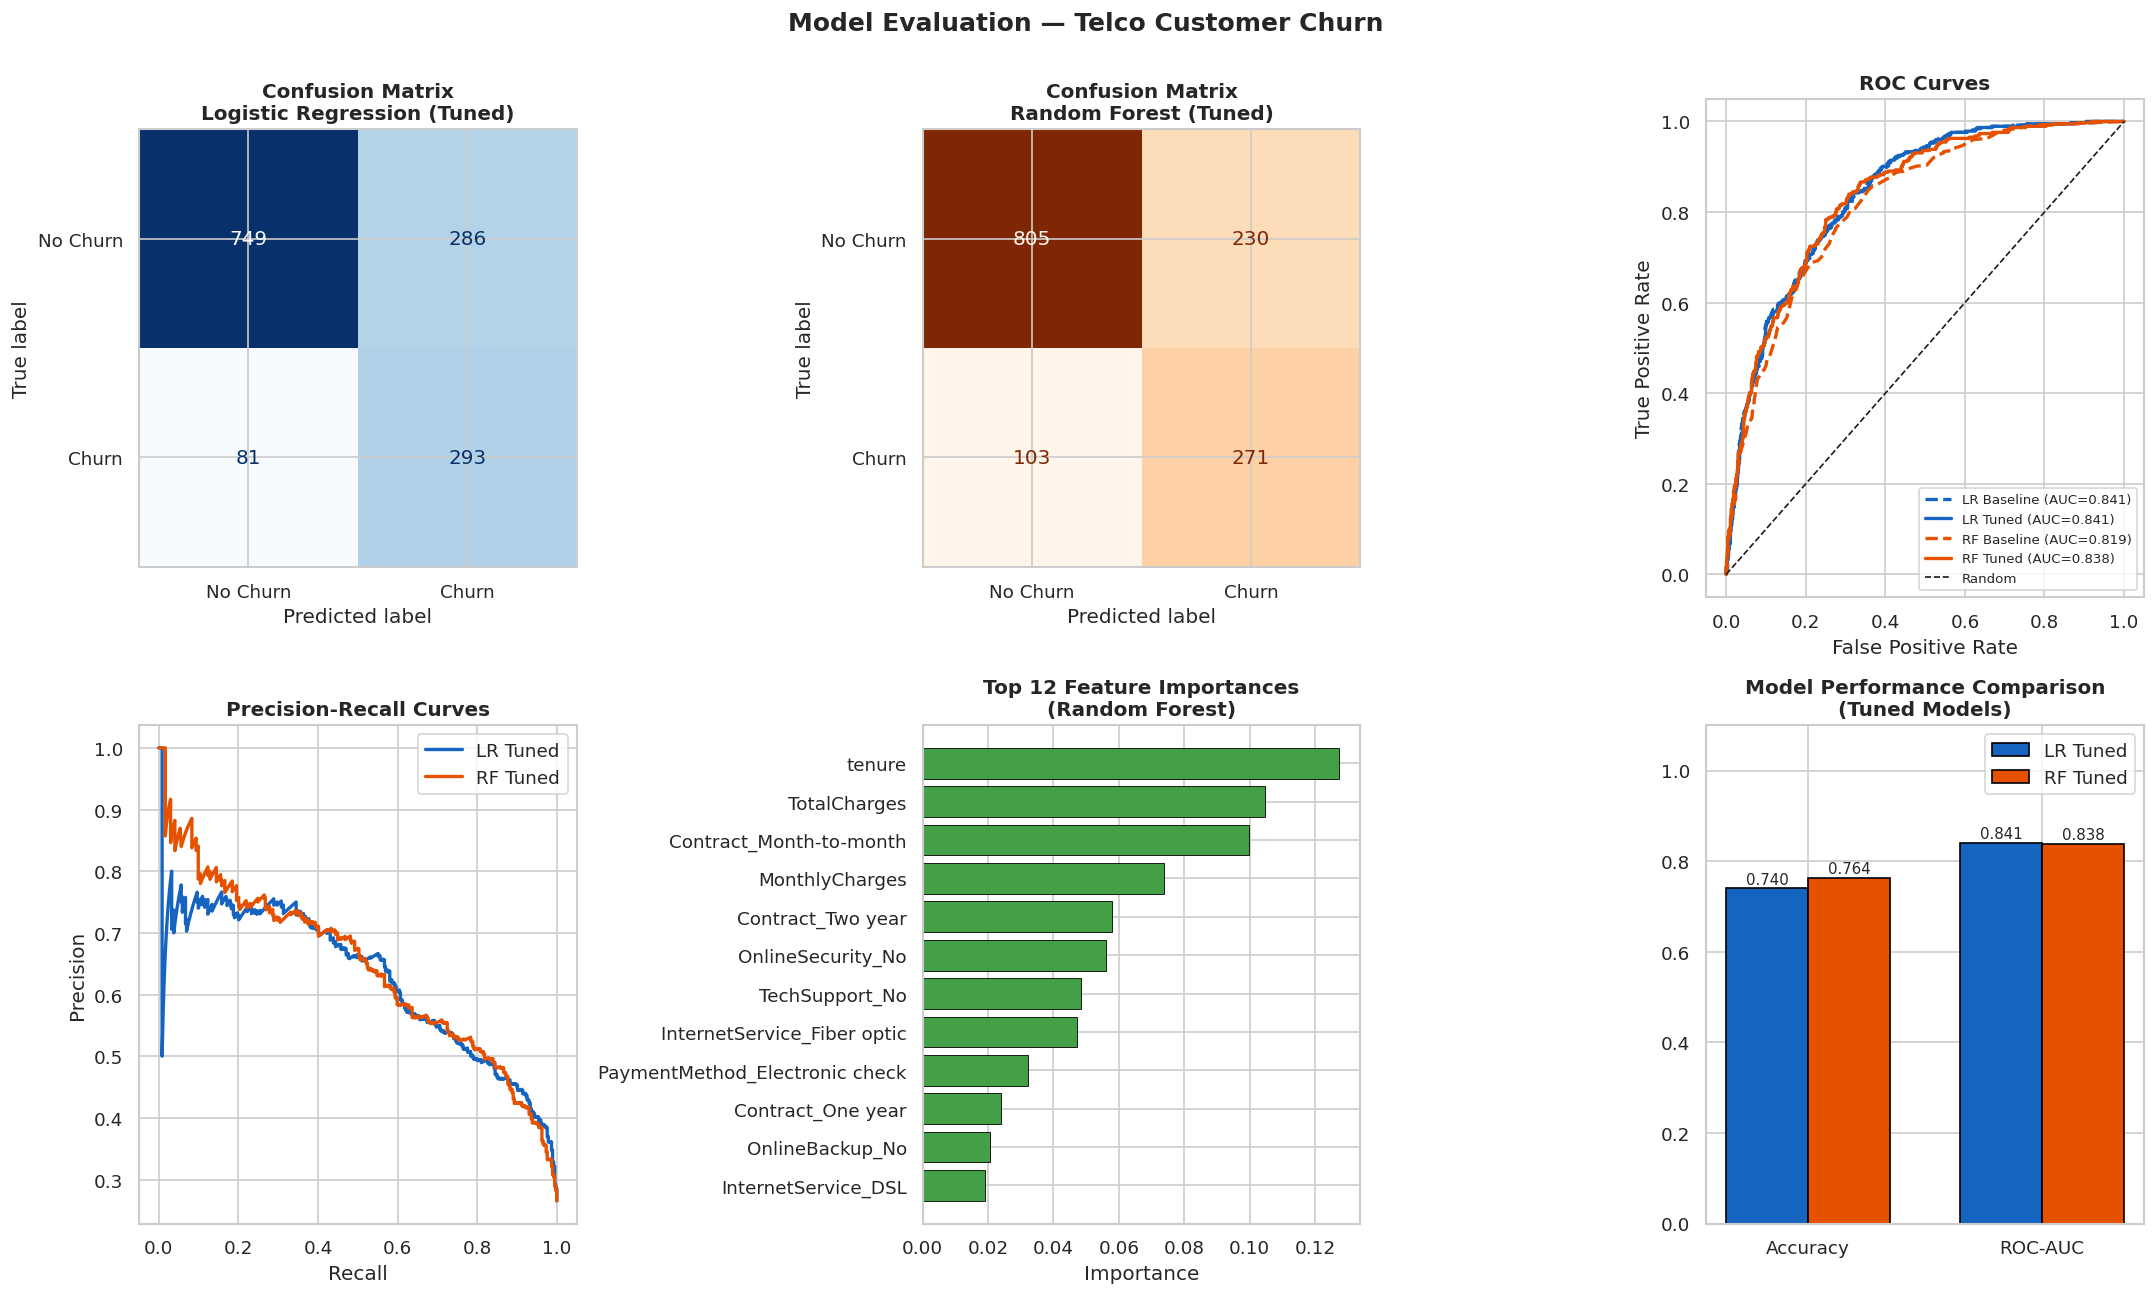

Evaluation plots saved!


In [14]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Model Evaluation — Telco Customer Churn', fontsize=15, fontweight='bold')

# ── 1. Confusion Matrix — LR Tuned ───────────────────────────────
cm_lr = confusion_matrix(y_test, lr_pred_tuned)
disp = ConfusionMatrixDisplay(cm_lr, display_labels=['No Churn', 'Churn'])
disp.plot(ax=axes[0,0], colorbar=False, cmap='Blues')
axes[0,0].set_title('Confusion Matrix\nLogistic Regression (Tuned)', fontweight='bold')

# ── 2. Confusion Matrix — RF Tuned ────────────────────────────────
cm_rf = confusion_matrix(y_test, rf_pred_tuned)
disp2 = ConfusionMatrixDisplay(cm_rf, display_labels=['No Churn', 'Churn'])
disp2.plot(ax=axes[0,1], colorbar=False, cmap='Oranges')
axes[0,1].set_title('Confusion Matrix\nRandom Forest (Tuned)', fontweight='bold')

# ── 3. ROC Curves ─────────────────────────────────────────────────
for name, proba, color, ls in [
    ('LR Baseline',  lr_pred_proba,       '#1565C0', '--'),
    ('LR Tuned',     lr_pred_proba_tuned, '#1565C0', '-'),
    ('RF Baseline',  rf_pred_proba,       '#E65100', '--'),
    ('RF Tuned',     rf_pred_proba_tuned, '#E65100', '-'),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes[0,2].plot(fpr, tpr, color=color, ls=ls,
                   lw=2, label=f'{name} (AUC={auc:.3f})')
axes[0,2].plot([0,1], [0,1], 'k--', lw=1, label='Random')
axes[0,2].set_xlabel('False Positive Rate')
axes[0,2].set_ylabel('True Positive Rate')
axes[0,2].set_title('ROC Curves', fontweight='bold')
axes[0,2].legend(fontsize=8)

# ── 4. Precision-Recall Curves ────────────────────────────────────
for name, proba, color, ls in [
    ('LR Tuned', lr_pred_proba_tuned, '#1565C0', '-'),
    ('RF Tuned', rf_pred_proba_tuned, '#E65100', '-'),
]:
    prec, rec, _ = precision_recall_curve(y_test, proba)
    axes[1,0].plot(rec, prec, color=color, lw=2, label=name)
axes[1,0].set_xlabel('Recall')
axes[1,0].set_ylabel('Precision')
axes[1,0].set_title('Precision-Recall Curves', fontweight='bold')
axes[1,0].legend()

# ── 5. Feature Importances — Random Forest ────────────────────────
# Get feature names after one-hot encoding
ohe = best_rf.named_steps['preprocessor'].named_transformers_['cat'].named_steps['encoder']
cat_feat_names = ohe.get_feature_names_out(CATEGORICAL_FEATURES).tolist()
all_feat_names = NUMERIC_FEATURES + cat_feat_names

importances = best_rf.named_steps['classifier'].feature_importances_
feat_imp_df = pd.DataFrame({'Feature': all_feat_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values('Importance', ascending=False).head(12)

axes[1,1].barh(feat_imp_df['Feature'], feat_imp_df['Importance'],
               color='#43A047', edgecolor='black', linewidth=0.5)
axes[1,1].set_title('Top 12 Feature Importances\n(Random Forest)', fontweight='bold')
axes[1,1].set_xlabel('Importance')
axes[1,1].invert_yaxis()

# ── 6. GridSearch CV scores ───────────────────────────────────────
metrics = ['Accuracy', 'ROC-AUC']
lr_vals = [accuracy_score(y_test, lr_pred_tuned), roc_auc_score(y_test, lr_pred_proba_tuned)]
rf_vals = [accuracy_score(y_test, rf_pred_tuned), roc_auc_score(y_test, rf_pred_proba_tuned)]
x = np.arange(len(metrics))
w = 0.35
bars1 = axes[1,2].bar(x - w/2, lr_vals, w, label='LR Tuned',  color='#1565C0', edgecolor='black')
bars2 = axes[1,2].bar(x + w/2, rf_vals, w, label='RF Tuned',  color='#E65100', edgecolor='black')
axes[1,2].set_xticks(x)
axes[1,2].set_xticklabels(metrics)
axes[1,2].set_ylim(0, 1.1)
axes[1,2].set_title('Model Performance Comparison\n(Tuned Models)', fontweight='bold')
axes[1,2].legend()
for bar in bars1:
    axes[1,2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                   f'{bar.get_height():.3f}', ha='center', fontsize=9)
for bar in bars2:
    axes[1,2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                   f'{bar.get_height():.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Evaluation plots saved!')

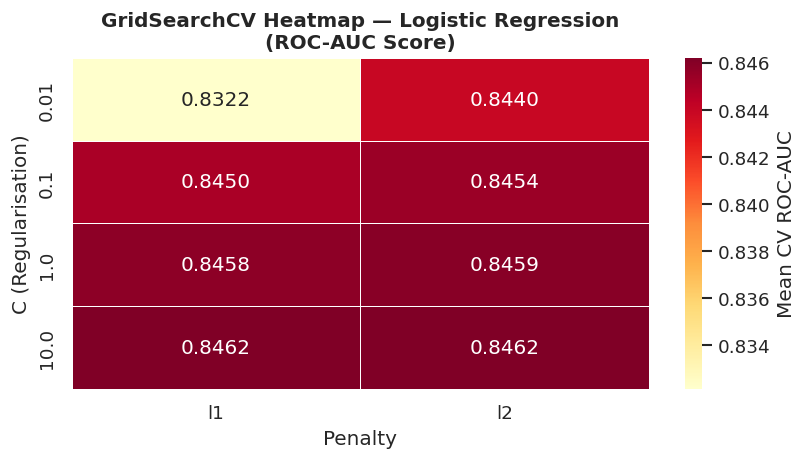

GridSearch heatmap saved!


In [15]:
# ── GridSearch Heatmap — LR ───────────────────────────────────────
lr_results = pd.DataFrame(lr_grid_search.cv_results_)

# Pivot: C vs penalty
pivot = lr_results.pivot_table(
    values='mean_test_score',
    index='param_classifier__C',
    columns='param_classifier__penalty'
)

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Mean CV ROC-AUC'})
ax.set_title('GridSearchCV Heatmap — Logistic Regression\n(ROC-AUC Score)', fontweight='bold')
ax.set_xlabel('Penalty')
ax.set_ylabel('C (Regularisation)')
plt.tight_layout()
plt.savefig('gridsearch_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('GridSearch heatmap saved!')

## Step 9 — Export Complete Pipeline with joblib

In [16]:
# ── Determine best overall model ──────────────────────────────────
lr_auc = roc_auc_score(y_test, lr_pred_proba_tuned)
rf_auc = roc_auc_score(y_test, rf_pred_proba_tuned)

if rf_auc >= lr_auc:
    best_model        = best_rf
    best_model_name   = 'Random Forest'
    best_model_auc    = rf_auc
else:
    best_model        = best_lr
    best_model_name   = 'Logistic Regression'
    best_model_auc    = lr_auc

print(f'Best overall model: {best_model_name} (AUC = {best_model_auc:.4f})')

# ── Export both pipelines ─────────────────────────────────────────
os.makedirs('saved_models', exist_ok=True)

joblib.dump(best_lr, 'saved_models/lr_pipeline.joblib')
joblib.dump(best_rf, 'saved_models/rf_pipeline.joblib')
joblib.dump(best_model, 'saved_models/best_pipeline.joblib')

# Save metadata
metadata = {
    'best_model'       : best_model_name,
    'best_params_lr'   : lr_grid_search.best_params_,
    'best_params_rf'   : rf_grid_search.best_params_,
    'lr_auc'           : round(lr_auc, 4),
    'rf_auc'           : round(rf_auc, 4),
    'lr_accuracy'      : round(accuracy_score(y_test, lr_pred_tuned), 4),
    'rf_accuracy'      : round(accuracy_score(y_test, rf_pred_tuned), 4),
    'numeric_features' : NUMERIC_FEATURES,
    'categorical_features': CATEGORICAL_FEATURES
}
joblib.dump(metadata, 'saved_models/metadata.joblib')

# Check file sizes
print()
print('Exported models:')
for fname in os.listdir('saved_models'):
    path = f'saved_models/{fname}'
    size_kb = os.path.getsize(path) / 1024
    print(f'  {fname:<30} {size_kb:.1f} KB')

Best overall model: Logistic Regression (AUC = 0.8406)

Exported models:
  best_pipeline.joblib           8.4 KB
  metadata.joblib                0.8 KB
  rf_pipeline.joblib             10952.9 KB
  lr_pipeline.joblib             8.4 KB


In [17]:
# ── Verify export — reload and predict ───────────────────────────
loaded_pipeline = joblib.load('saved_models/best_pipeline.joblib')

# Take 3 test samples
sample_X = X_test.iloc[:3].copy()
sample_y = y_test.iloc[:3].values

sample_pred  = loaded_pipeline.predict(sample_X)
sample_proba = loaded_pipeline.predict_proba(sample_X)[:, 1]

print('Pipeline loaded and verified successfully!')
print()
print('Sample predictions on 3 test customers:')
for i, (actual, pred, prob) in enumerate(zip(sample_y, sample_pred, sample_proba)):
    status = '✓' if actual == pred else '✗'
    print(f'  Customer {i+1}: Actual={"Churn" if actual==1 else "No Churn"}  '
          f'Predicted={"Churn" if pred==1 else "No Churn"}  '
          f'Prob={prob:.2%}  {status}')

Pipeline loaded and verified successfully!

Sample predictions on 3 test customers:
  Customer 1: Actual=No Churn  Predicted=No Churn  Prob=12.16%  ✓
  Customer 2: Actual=No Churn  Predicted=Churn  Prob=85.15%  ✗
  Customer 3: Actual=No Churn  Predicted=No Churn  Prob=12.72%  ✓


## Step 10 — Cross-Validation (Final Reliability Check)

In [18]:
# 5-fold stratified CV on full dataset
print('Running 5-fold cross-validation on full dataset...')
print()

for name, model in [('Logistic Regression', best_lr), ('Random Forest', best_rf)]:
    cv_scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
    print(f'{name}:')
    print(f'  CV AUC scores : {[round(s,4) for s in cv_scores]}')
    print(f'  Mean ± Std    : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
    print()

Running 5-fold cross-validation on full dataset...

Logistic Regression:
  CV AUC scores : [np.float64(0.8552), np.float64(0.846), np.float64(0.8621), np.float64(0.8254), np.float64(0.8363)]
  Mean ± Std    : 0.8450 ± 0.0131

Random Forest:
  CV AUC scores : [np.float64(0.8551), np.float64(0.8414), np.float64(0.8587), np.float64(0.8235), np.float64(0.8373)]
  Mean ± Std    : 0.8432 ± 0.0127



## Step 11 — Final Summary & Insights

In [19]:
lr_acc  = accuracy_score(y_test, lr_pred_tuned)
rf_acc  = accuracy_score(y_test, rf_pred_tuned)

print('=' * 65)
print('   FINAL SUMMARY & INSIGHTS — TASK 2: ML PIPELINE')
print('=' * 65)
print(f"""
DATASET
  • Source    : IBM Telco Customer Churn (7,043 customers, 20 features)
  • Target    : Churn (Yes=1 / No=0) — {df['Churn'].mean():.1%} churn rate
  • Split     : 80% train / 20% test (stratified)

PIPELINE ARCHITECTURE
  Numeric  ({len(NUMERIC_FEATURES)} cols) → SimpleImputer(median) → StandardScaler
  Categorical ({len(CATEGORICAL_FEATURES)} cols) → SimpleImputer(mode) → OneHotEncoder
  Combined via ColumnTransformer → Classifier

TUNED MODEL RESULTS (Test Set)
  {'Model':<25} {'Accuracy':>10} {'ROC-AUC':>10}
  {'-'*47}
  {'Logistic Regression':<25} {lr_acc:>10.4f} {lr_auc:>10.4f}
  {'Random Forest':<25} {rf_acc:>10.4f} {rf_auc:>10.4f}

BEST MODEL : {best_model_name} (AUC = {best_model_auc:.4f})
  Best params: {rf_grid_search.best_params_ if best_model_name=='Random Forest' else lr_grid_search.best_params_}

KEY INSIGHTS
  1. Month-to-month contract customers churn far more than long-term
     contract customers — contract type is a top predictor.
  2. Fiber optic internet users have higher churn — potentially due to
     higher monthly charges without perceived value.
  3. Tenure is strongly negatively correlated with churn: new customers
     are much more likely to leave.
  4. class_weight='balanced' significantly improved recall for the
     minority (churn) class — critical for business impact.
  5. GridSearchCV found that RF with shallow trees (max_depth=10–20)
     generalises better than fully grown trees (avoids overfitting).
  6. The exported joblib pipeline is deployment-ready: load + predict
     on raw customer data with no preprocessing needed.

SKILLS DEMONSTRATED
  ✓ ML pipeline construction (Scikit-learn Pipeline API)
  ✓ Hyperparameter tuning with GridSearchCV
  ✓ Model export and reusability (joblib)
  ✓ Production-readiness practices (ColumnTransformer, stratified CV)
""")

   FINAL SUMMARY & INSIGHTS — TASK 2: ML PIPELINE

DATASET
  • Source    : IBM Telco Customer Churn (7,043 customers, 20 features)
  • Target    : Churn (Yes=1 / No=0) — 26.5% churn rate
  • Split     : 80% train / 20% test (stratified)

PIPELINE ARCHITECTURE
  Numeric  (4 cols) → SimpleImputer(median) → StandardScaler
  Categorical (15 cols) → SimpleImputer(mode) → OneHotEncoder
  Combined via ColumnTransformer → Classifier

TUNED MODEL RESULTS (Test Set)
  Model                       Accuracy    ROC-AUC
  -----------------------------------------------
  Logistic Regression           0.7395     0.8406
  Random Forest                 0.7637     0.8379

BEST MODEL : Logistic Regression (AUC = 0.8406)
  Best params: {'classifier__C': 10.0, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}

KEY INSIGHTS
  1. Month-to-month contract customers churn far more than long-term
     contract customers — contract type is a top predictor.
  2. Fiber optic internet users have higher 